# Configuración inicial

In [13]:
from image_video_detection import VideoProcessor
import time
from IPython.display import Video, display
import os

print("Iniciando...")
ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
MEDIA_DIR = os.path.join(ROOT, "Media")
VIDEOS_DIR = os.path.join(MEDIA_DIR, "Videos")
IMAGES_DIR = os.path.join(MEDIA_DIR, "Images")
VIDEO1_PATH = os.path.join(VIDEOS_DIR, "TheaterSquare_1280x720.mp4")
VIDEO2_PATH = os.path.join(VIDEOS_DIR, "NovosobornayaSquare_1920x1080.mp4") # Absolute path
VIDEO3_PATH = os.path.join(VIDEOS_DIR, "TSU_1920x1080.mp4")


VIDEO_PATHS = [VIDEO1_PATH]

PXT_DIRECTORY = "Detection"
YOLOX_MODEL = "yolox_m"
CONFIDENCE_THRESHOLD = 0.25
FPS = 10
EMBED_MODEL = 'openai/clip-vit-base-patch32'
videos = VideoProcessor(PXT_DIRECTORY,
                        YOLOX_MODEL,
                        CONFIDENCE_THRESHOLD,
                        FPS,
                        EMBED_MODEL)

print("Hecho")
print("PATH: ", VIDEO2_PATH)
display(Video(VIDEO2_PATH, embed=True, width=400))

Iniciando...
Hecho
PATH:  C:\Dev\PPS\Media\Videos\NovosobornayaSquare_1920x1080.mp4


## Setup 

In [15]:
start = time.time()
print("Empezando setup...")
videos.setup()
end = time.time()
print(f"Setup terminado ({end - start:.2f} s)")

Empezando setup...
Created table `Detection`.
Created view `frames` with 0 rows, 0 exceptions.
Added 0 column values with 0 errors.
Added 0 column values with 0 errors.
Setup terminado (0.15 s)


## Carga de videos

In [16]:
start = time.time()
print("Empezando procesamiento...")
videos.process_videos(VIDEO_PATHS)
end = time.time()
print(f"Procesamiento terminado ({end - start:.2f} s)")

Empezando procesamiento...
Inserting rows into `Detection`: 1 rows [00:00, 177.45 rows/s]
Inserting rows into `frames`: 100 rows [00:00, 273.97 rows/s]
Inserted 101 rows with 100 errors across 1 column (frames.raw_detections).
Procesamiento terminado (7.43 s)


## Búsqueda de videos

Empezando búsqueda...
Usando una imagen como query:


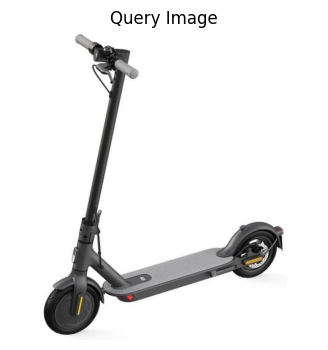


Encontrados 5 resultados para la búsqueda por imagen:


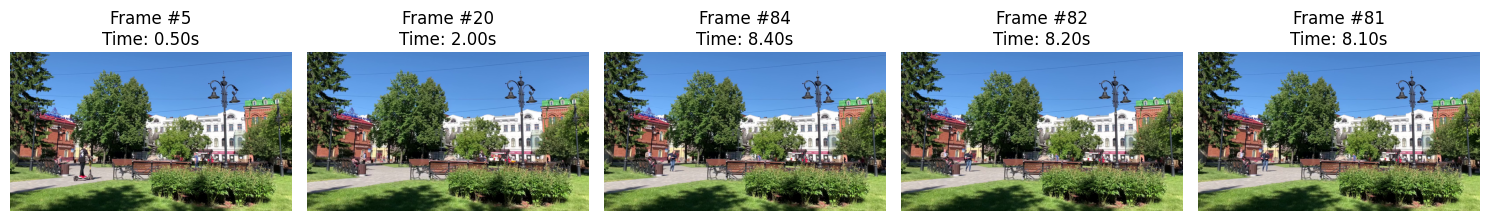

Búsqueda terminada (0.83 s)


In [17]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image 

path_image_query = os.path.join(IMAGES_DIR, "monopatin_electrico.jpg")

start = time.time()
print("Empezando búsqueda...")

if videos.frames_view is None or videos.frames_view.count() == 0:
    print("No hay frames para buscar, cargá los datos")
    results = []
else:
    try:
        if path_image_query.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
            # Load image directly if it's an image file
            image_search_query = Image.open(path_image_query)
        else:
            video_cap = cv2.VideoCapture(path_image_query)
            success, frame = video_cap.read()
            video_cap.release()
            
            if not success:
                raise Exception(f"No se pudo leer el archivo {path_image_query}")
                
            # Convert from BGR to RGB (OpenCV uses BGR by default)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Convert to PIL Image for compatibility with Pixeltable
            image_search_query = Image.fromarray(frame_rgb)
        
        print("Usando una imagen como query:")
        
        plt.figure(figsize=(6, 4))
        plt.imshow(np.array(image_search_query))
        plt.title("Query Image")
        plt.axis('off')
        plt.show()

        # Perform the search
        search_type = "Image"
        results = videos.search_video(
            search_type, 
            text_search_query=None,
            image_query=image_search_query,
            limit=5
        )
                
        if results:
            print(f"\nEncontrados {len(results)} resultados para la búsqueda por imagen:")
            
            fig, axes = plt.subplots(1, len(results), figsize=(15, 5))
            if len(results) == 1:
                axes = [axes]
                
            for r_idx, result in enumerate(results):
                pos_time = result.get('pos', 'N/A')
                frame = result.get('frame')
                
                # Posición a segundos
                time_str = f"Frame #{pos_time}"
                if isinstance(pos_time, (int, float)):
                    seconds = pos_time / videos.fps if videos.fps > 0 else pos_time
                    time_str = f"Frame #{pos_time}\nTime: {seconds:.2f}s"
                
                # Display in matplotlib subplot
                axes[r_idx].imshow(np.array(frame))
                axes[r_idx].set_title(time_str)
                axes[r_idx].axis('off')
            
            plt.tight_layout()
            plt.show()
        else:
            print("No se encontraron resultados para la búsqueda por imagen.")
            
    except Exception as e:
        print(f"Error en ejecución: {e}")
        results = []

end = time.time()
print(f"Búsqueda terminada ({end - start:.2f} s)")